# Phishing URL Behaviour Classification — EDA & Model Comparison
Learn Depth Academy · Track 1 Capstone · Problem 02

This notebook covers D2 (data) and D3 (EDA) from the 10-day plan, then reproduces
the model comparison from `src/train.py` (D4-D6) with a bit more explanation and
plots than the plain script.

**Dataset:** Hannousse & Yahiouche (2021) — 11,430 URLs, balanced 50/50,
raw URL text + 87 pre-engineered features + status label.
We only use the raw `url` column here; features are re-derived ourselves in
`src/url_features.py` so training and the Streamlit app stay perfectly consistent.


In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('../src'))
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from url_features import extract_features_vector, FEATURE_NAMES

pd.set_option('display.max_columns', 50)
plt.rcParams['figure.figsize'] = (7, 4)
sns.set_style('whitegrid')


## 1. Load the data

In [2]:
df = pd.read_csv('../data/hannousse_raw.csv')
print(df.shape)
df[['url', 'status']].head()


(11430, 89)


,url,status
0,http://www.crestonwood.com/router.php,legitimate
1,http://shadetreetechnology.com/V4/validation/a...,phishing
2,https://support-appleld.com.secureupdate.duila...,phishing
3,http://rgipt.ac.in,legitimate
4,http://www.iracing.com/tracks/gateway-motorspo...,legitimate


## 2. Data quality checks
Missing values, duplicates, class balance — exactly what the capstone brief's
"Investigation Areas" asks for.

Missing values per column (top 5):
url                0
length_url         0
length_hostname    0
ip                 0
nb_dots            0
dtype: int64

Duplicate URLs: 1

Class balance:
status
legitimate    5715
phishing      5715
Name: count, dtype: int64


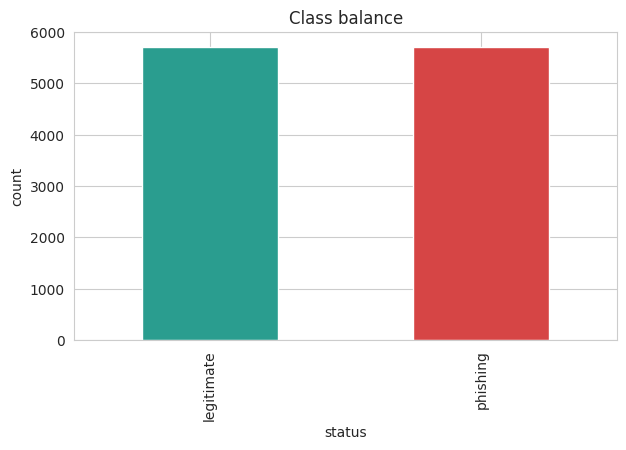

In [3]:
print('Missing values per column (top 5):')
print(df.isna().sum().sort_values(ascending=False).head())
print()
print('Duplicate URLs:', df['url'].duplicated().sum())
print()
print('Class balance:')
print(df['status'].value_counts())
df['status'].value_counts().plot(kind='bar', color=['#2A9D8F', '#D64545'])
plt.title('Class balance'); plt.ylabel('count'); plt.show()


## 3. Build our own features from the raw URL
We deliberately do NOT use the 87 pre-engineered columns already in the CSV.
Instead we recompute a smaller, URL-only feature set ourselves
(`url_features.py`), so the exact same code can run inside the Streamlit app
on a URL nobody has seen before.

In [4]:
df = df.drop_duplicates(subset='url').dropna(subset=['url', 'status'])
feats = df['url'].apply(extract_features_vector)
X = pd.DataFrame(feats.tolist(), columns=FEATURE_NAMES)
y = (df['status'].str.lower() == 'phishing').astype(int).reset_index(drop=True)
X = X.reset_index(drop=True)
X.describe().T[['mean', 'std', 'min', 'max']]


,mean,std,min,max
length_url,61.120658,55.294849,12.0,1641.0000
length_hostname,21.089859,10.777545,4.0,214.0000
ip,0.008487,0.091738,0.0,1.0000
nb_dots,2.480532,1.369671,1.0,24.0000
nb_hyphens,0.997638,2.087157,0.0,43.0000
nb_at,0.022224,0.155507,0.0,4.0000
nb_qm,0.141220,0.364469,0.0,3.0000
nb_and,0.162306,0.821372,0.0,19.0000
nb_eq,0.293202,0.998357,0.0,19.0000
nb_underscore,0.322688,1.093379,0.0,18.0000


## 4. Distributions: legitimate vs phishing
A quick look at whether our features actually separate the two classes.

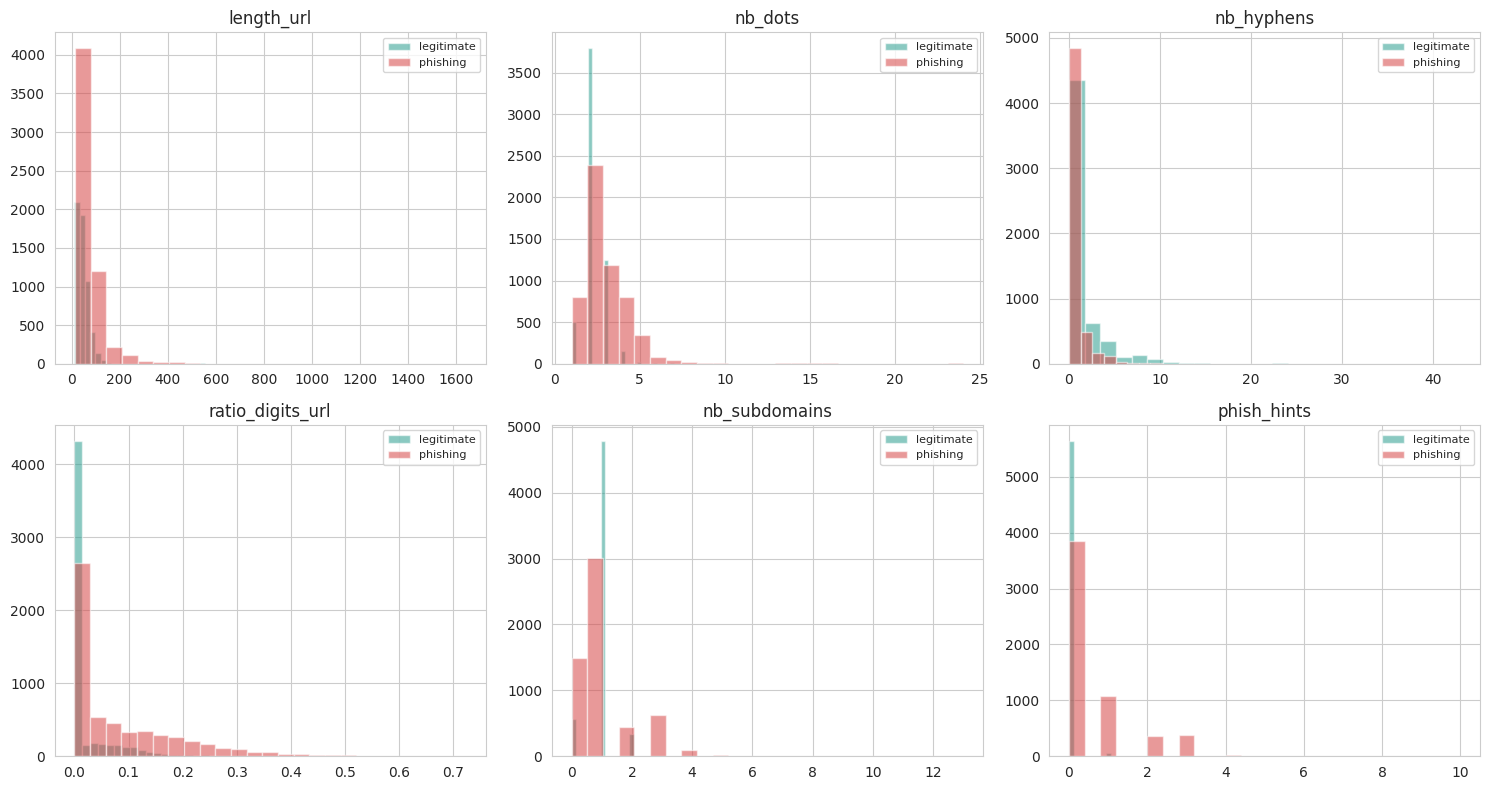

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
show_feats = ['length_url', 'nb_dots', 'nb_hyphens', 'ratio_digits_url', 'nb_subdomains', 'phish_hints']
for ax, feat in zip(axes.ravel(), show_feats):
    for label, color in [(0, '#2A9D8F'), (1, '#D64545')]:
        subset = X[feat][y == label]
        ax.hist(subset, bins=25, alpha=0.55, label='legitimate' if label==0 else 'phishing', color=color)
    ax.set_title(feat); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()


## 5. Correlation heatmap (check for redundant / leaking features)

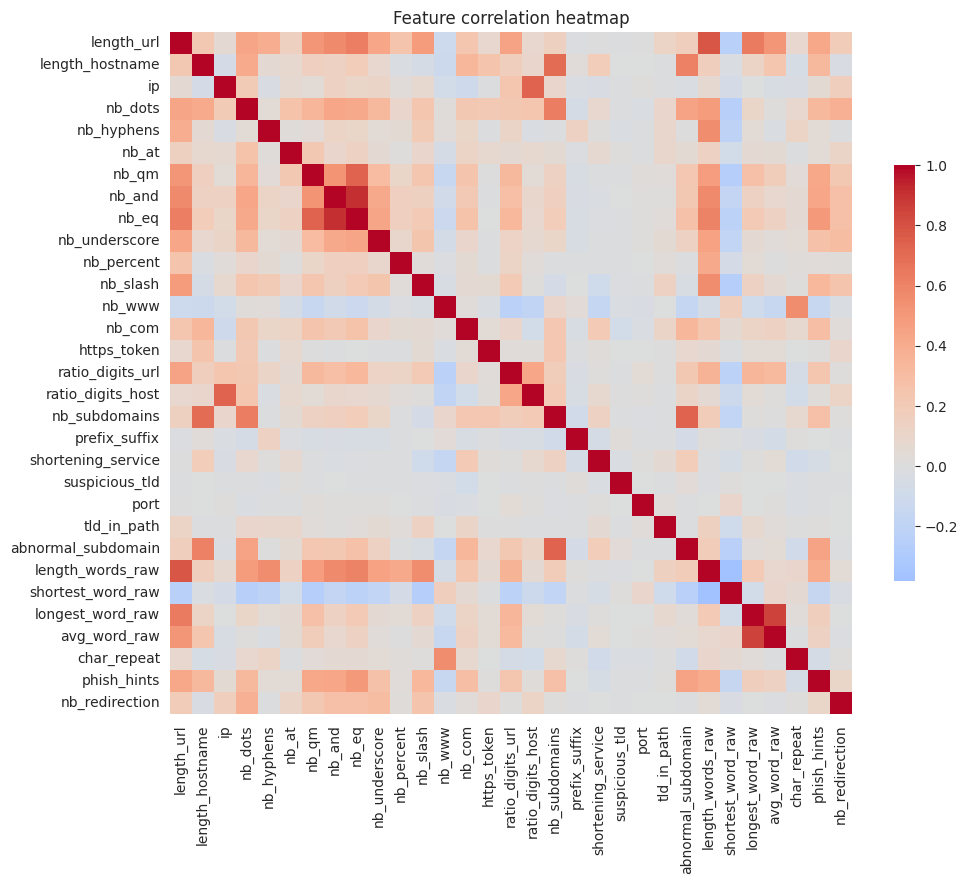

Top 10 features by |correlation| with label:
nb_www               -0.463140
phish_hints           0.365729
ratio_digits_url      0.356419
nb_qm                 0.294368
abnormal_subdomain    0.263603
length_url            0.248504
nb_slash              0.242210
length_hostname       0.238295
nb_eq                 0.233423
ratio_digits_host     0.224243
dtype: float64


In [6]:
plt.figure(figsize=(11, 9))
corr = X.corr()
sns.heatmap(corr, cmap='coolwarm', center=0, square=True, cbar_kws={'shrink': .6})
plt.title('Feature correlation heatmap'); plt.show()

corr_with_label = X.apply(lambda col: np.corrcoef(col, y)[0, 1]).sort_values(key=abs, ascending=False)
print('Top 10 features by |correlation| with label:')
print(corr_with_label.head(10))


## 6. Train / test split + scaling
80/20 stratified split. Scaler is fit on TRAIN only (see Note 2, Section 5.4 and
Note 1's data-leakage warning).

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train)
X_test_s = scaler.transform(X_test)
print(X_train.shape, X_test.shape)


(9143, 31) (2286, 31)


## 7. Train the three foundational models
(Same models/params as `src/train.py`; see that file for the full grid search.)

In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, RocCurveDisplay)

models = {
    'Logistic Regression': LogisticRegression(max_iter=3000, C=10, random_state=42),
    'KNN (k=11, distance)': KNeighborsClassifier(n_neighbors=11, weights='distance'),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
}

results = {}
for name, model in models.items():
    model.fit(X_train_s, y_train)
    pred = model.predict(X_test_s)
    proba = model.predict_proba(X_test_s)[:, 1]
    results[name] = dict(
        accuracy=accuracy_score(y_test, pred),
        precision=precision_score(y_test, pred),
        recall=recall_score(y_test, pred),
        f1=f1_score(y_test, pred),
        roc_auc=roc_auc_score(y_test, proba),
    )
pd.DataFrame(results).T.round(4)


,accuracy,precision,recall,f1,roc_auc
Logistic Regression,0.8381,0.8569,0.8119,0.8338,0.9228
"KNN (k=11, distance)",0.8784,0.8791,0.8775,0.8783,0.9452
Decision Tree,0.8640,0.8649,0.8626,0.8638,0.8657


## 8. Confusion matrices

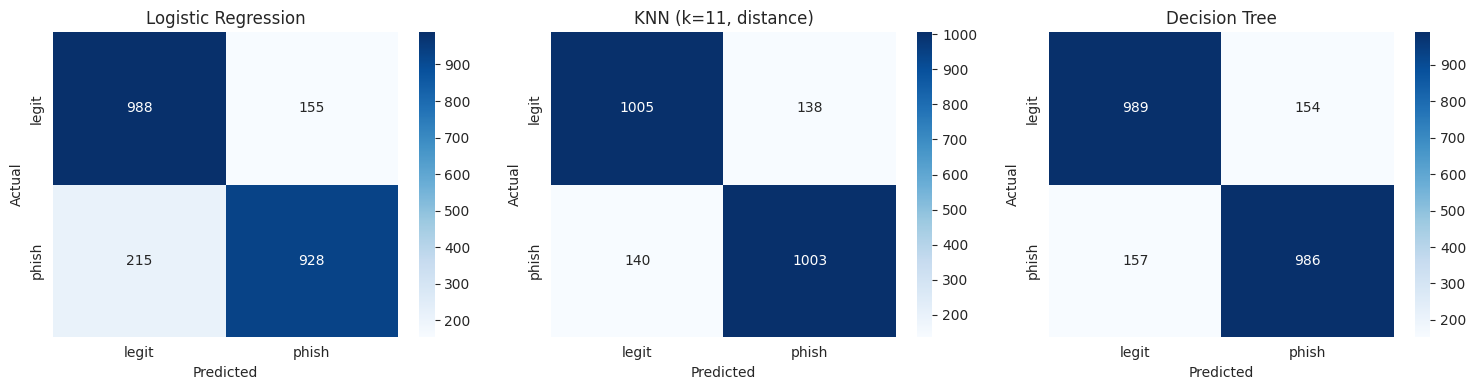

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, model) in zip(axes, models.items()):
    pred = model.predict(X_test_s)
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['legit', 'phish'], yticklabels=['legit', 'phish'])
    ax.set_title(name); ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.tight_layout(); plt.show()


## 9. ROC curves

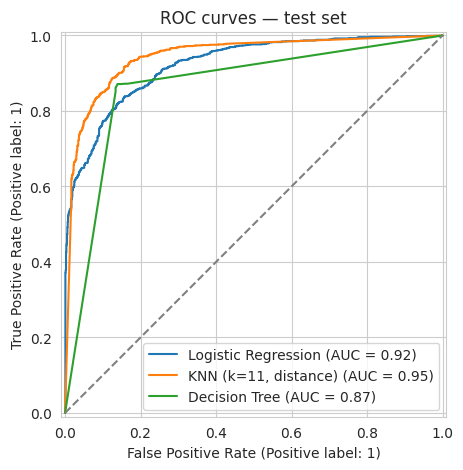

In [10]:
fig, ax = plt.subplots(figsize=(6, 5))
for name, model in models.items():
    RocCurveDisplay.from_estimator(model, X_test_s, y_test, ax=ax, name=name)
ax.plot([0, 1], [0, 1], '--', color='grey')
ax.set_title('ROC curves — test set')
plt.show()


## 10. Discussion
- All three models land in a similar 0.83-0.88 F1 range on lexical-only features —
  consistent with the literature (Note 1, Section 6), which shows lexical features
  alone carry real signal but content/domain features push accuracy higher
  (see `reports/metrics_cross_dataset.md` for the UCI-30 / Grega-111 comparison,
  which score 0.90-0.97 F1 once those extra feature types are allowed).
- KNN (k=11, distance-weighted) was chosen for the deployed app: best test F1,
  and prediction cost is negligible for a single pasted URL.
- Decision Tree remains attractive for explainability in the viva (thresholds are
  easy to read aloud), even though its raw F1 is a touch lower than KNN's.
- No feature showed a suspiciously perfect correlation with the label (max ~0.46),
  which is evidence against obvious data leakage in this feature set.
